# Regularization, Cross-Validation & GridSearch

**The question of this notebook:** how do we choose a model's hyperparameters (here: the regularization strength) *without cheating on the test set*?

We use the Advertising dataset (predict `sales` from `TV`, `radio` and `newspaper` budgets) and answer that question four times, each time a bit better:

| Part | How we choose the hyperparameter | Problem it leaves |
|---|---|---|
| 1. Train / Test | Compare models on the test set | We tune on the test set, so the test score is no longer honest |
| 2. Train / Validation / Test | Compare models on a separate validation set | The result depends on one small, random validation split |
| 3. Cross-validation | Average the score over 5 validation folds | We still try every value by hand |
| 4. GridSearchCV | Try every combination automatically, with cross-validation | ✔ systematic and reliable |

The workflow stays the same in every part: **create X and y → split → scale (fit on train only) → build model → tune on non-test data → evaluate once on the test set.** Only the tuning method changes.

# Part 1: Regularization with Train | Test Split

0. Clean and adjust data as necessary for X and y
1. Split Data in Train/Test for both X and y
2. Fit/Train Scaler on Training X Data
3. Scale X Test Data
4. Create Model
5. Fit/Train Model on X Train Data
6. Evaluate Model on X Test Data (by creating predictions and comparing to Y_test)
7. Adjust Parameters as Necessary and repeat steps 5 and 6

## 0-Setup

### Imports

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 1-Data Loading and Exploration

In [6]:
df = pd.read_csv("datasets/Advertising.csv")

In [7]:
df.head()

,TV,radio,newspaper,sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


### Data Visualization

Let's explore the relationships between different advertising channels (TV, Radio, Newspaper) and Sales through various visualizations:

<Figure size 1000x800 with 0 Axes>

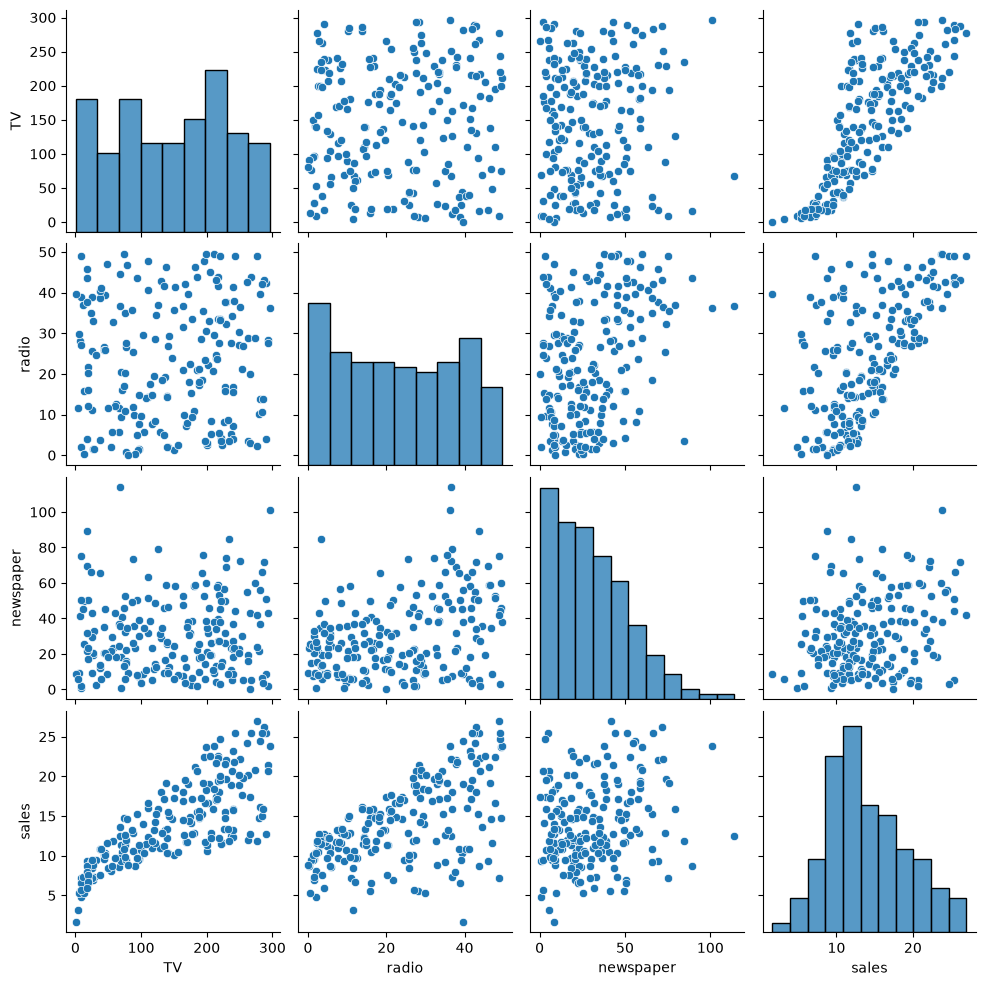

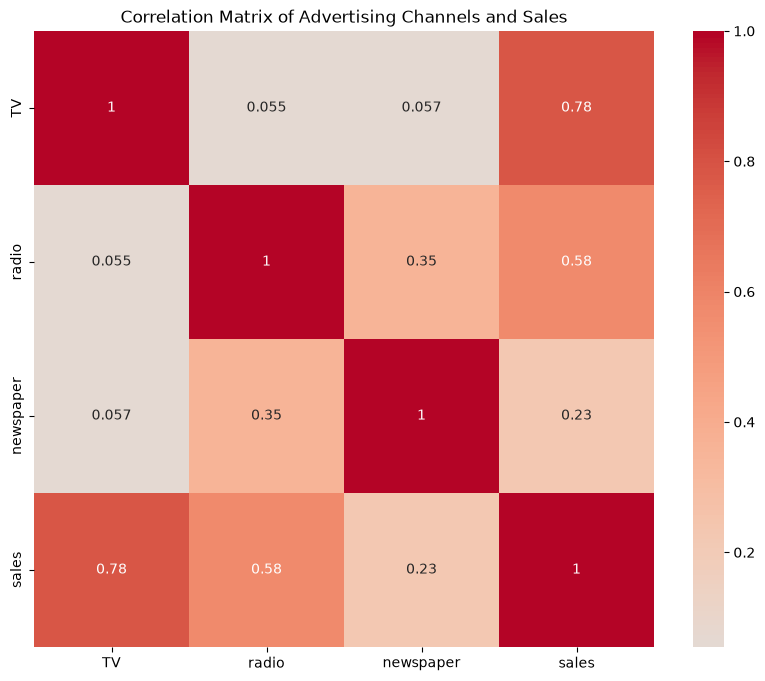

In [8]:
# Create a pairplot to show relationships between all variables
plt.figure(figsize=(10, 8))
sns.pairplot(df)
plt.show()

# Display correlation matrix heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix of Advertising Channels and Sales')
plt.show()

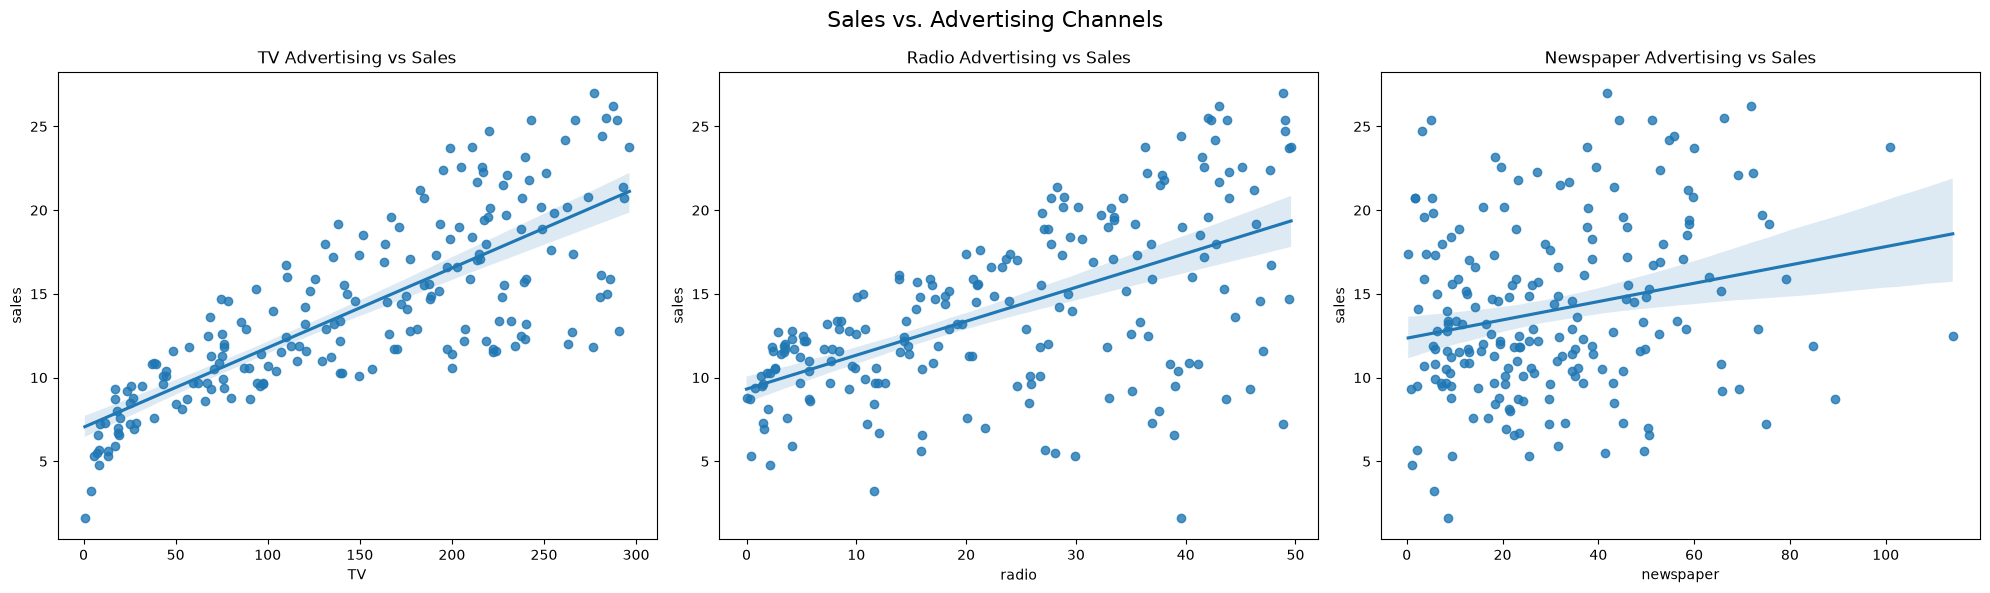

In [9]:
# Create individual scatter plots with regression lines
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Sales vs. Advertising Channels', fontsize=16)

# TV vs Sales
sns.regplot(data=df, x='TV', y='sales', ax=axes[0])
axes[0].set_title('TV Advertising vs Sales')

# Radio vs Sales
sns.regplot(data=df, x='radio', y='sales', ax=axes[1])
axes[1].set_title('Radio Advertising vs Sales')

# Newspaper vs Sales
sns.regplot(data=df, x='newspaper', y='sales', ax=axes[2])
axes[2].set_title('Newspaper Advertising vs Sales')

plt.tight_layout()
plt.show()

### Key Observations from Data Visualization

1. **Correlation Analysis**:
   - TV advertising shows the strongest positive correlation with sales
   - Radio advertising has a moderate positive correlation with sales
   - Newspaper advertising shows the weakest correlation with sales

2. **Relationships**:
   - TV: Shows a strong linear relationship with sales
   - Radio: Shows a moderate linear relationship with sales
   - Newspaper: Shows a weak and more scattered relationship with sales

3. **Interactions**:
   - There appears to be some interaction between different advertising channels
   - The correlation matrix shows relatively low correlation between different advertising methods
   - This suggests that each channel might contribute independently to sales

These insights will be valuable when we build and evaluate our regression models.

## 2-Data Processing

### Formatting Data

In [10]:
## CREATE X and y
X = df.drop('sales',axis=1)
y = df['sales']

# TRAIN TEST SPLIT
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=101)

### Feature Scaling (Standardization)

Our features are measured on very different scales: the TV budget goes up to about 300, the radio budget only up to about 50.

**Why does this matter for regularization?** 

Ridge and Lasso add a penalty on the *size* of the coefficients. But the size of a coefficient depends on the unit of its feature: if we measured the TV budget in thousands instead of in units, its coefficient would become 1000 times bigger, and so would its penalty. Without scaling, the penalty hits some features much harder than others, for no good reason. After scaling, all features are on the same scale, so the penalty treats them fairly (and the coefficients become comparable with each other).

**What does the `StandardScaler` do?** 

For every feature it subtracts the mean and divides by the standard deviation:

$$z = \frac{x - \text{mean}}{\text{standard deviation}}$$


After scaling, every feature has a mean of 0 and a standard deviation of 1. A scaled value tells you how many standard deviations a value lies above (+) or below (-) the average.

**Fit on the training set only!** 

The scaler *learns* the mean and standard deviation, so we fit it on `X_train` only, and use those same training values to transform `X_test`. Fitting it on the test set (or on all the data) would leak information from the test set into training.

Note: tree-based models (decision trees, random forests) don't need scaling: they split on one feature at a time, so the unit doesn't matter.

**Before scaling:** the features have very different means and spreads.

In [11]:
X_train.describe().round(2)

,TV,radio,newspaper
count,140.00,140.00,140.00
mean,151.66,23.41,31.11
std,84.56,14.80,21.49
min,0.70,0.00,1.00
25%,76.38,9.52,13.58
50%,157.40,23.75,25.90
75%,220.82,36.58,44.70
max,296.40,49.60,100.90


In [12]:
# SCALE DATA
from sklearn.preprocessing import StandardScaler

X_train_unscaled = X_train.copy()   # keep a copy, only to compare before and after

scaler = StandardScaler()
scaler.fit(X_train)                 # learn mean and standard deviation from the TRAINING data only
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)   # transform the test set with the training mean and standard deviation

What did the scaler learn from the training data?

In [13]:
pd.DataFrame({'mean': scaler.mean_, 'standard deviation': scaler.scale_}, index=X.columns).round(2)

,mean,standard deviation
TV,151.66,84.26
radio,23.41,14.74
newspaper,31.11,21.41


**After scaling:** every feature now has a mean of 0 and a standard deviation of 1 (the `std` row in the table). Note that the scaler returns a NumPy array, so we turn it back into a DataFrame to describe it.

In [14]:
pd.DataFrame(X_train, columns=X.columns).describe().round(2)

,TV,radio,newspaper
count,140.00,140.00,140.00
mean,0.00,0.00,-0.00
std,1.00,1.00,1.00
min,-1.79,-1.59,-1.41
25%,-0.89,-0.94,-0.82
50%,0.07,0.02,-0.24
75%,0.82,0.89,0.63
max,1.72,1.78,3.26


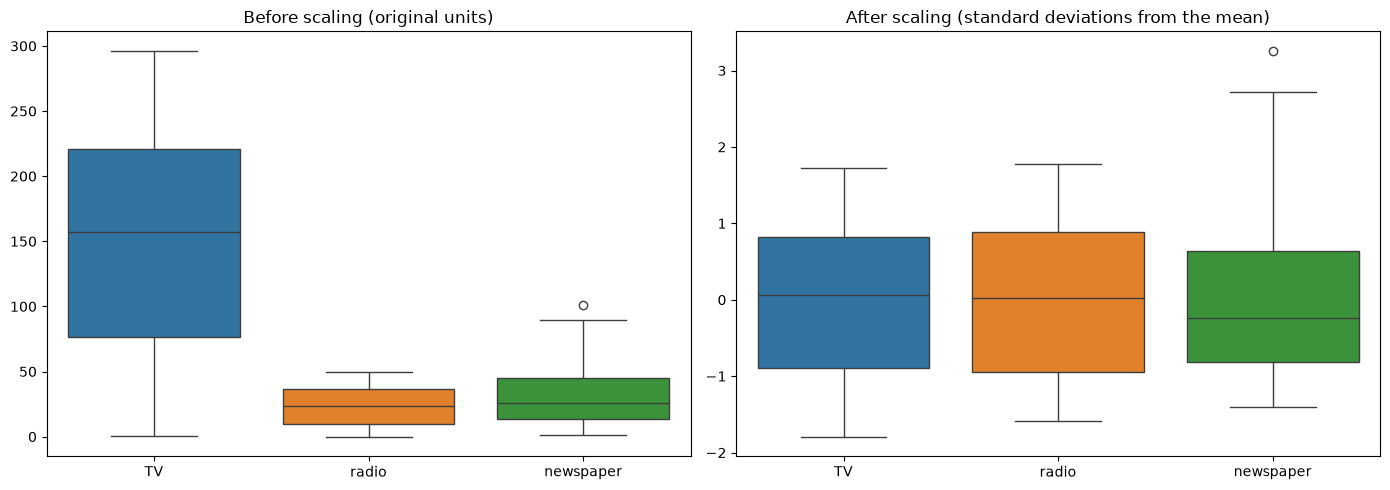

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=X_train_unscaled, ax=axes[0])
axes[0].set_title('Before scaling (original units)')

sns.boxplot(data=pd.DataFrame(X_train, columns=X.columns), ax=axes[1])
axes[1].set_title('After scaling (standard deviations from the mean)')

plt.tight_layout()
plt.show()

Scaling only shifts and stretches each feature: the *shape* of each distribution (and the order of the values) stays the same.

What about the test set? It was transformed with the *training* mean and standard deviation, so its mean is close to 0 but not exactly 0. That is expected, and it is exactly what we want: the test set has to be treated like new, unseen data.

In [16]:
pd.DataFrame(X_test, columns=X.columns).describe().loc[['mean', 'std']].round(2)

,TV,radio,newspaper
mean,-0.18,-0.03,-0.09
std,1.05,1.02,1.05


## 3-Model Building

### Linear Regression (no regularization)

In [17]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# Create a standard linear regression model without regularization
linreg_model = LinearRegression()

# Fit the model on the training data
linreg_model.fit(X_train, y_train)

# Make predictions on test data
y_pred_linreg = linreg_model.predict(X_test)

# Evaluate the model
linreg_mse = mean_squared_error(y_test, y_pred_linreg)

print(f"Linear Regression (no regularization) MSE: {linreg_mse}")

# Display coefficients for comparison with regularized models later
print("\nModel Coefficients:")
print(pd.DataFrame({'Feature': X.columns, 'Coefficient': linreg_model.coef_}))

Linear Regression (no regularization) MSE: 2.298716697886379

Model Coefficients:
     Feature  Coefficient
0         TV     3.765990
1      radio     2.765487
2  newspaper    -0.006910


### Ridge Regression with alpha = 100 (too much regularization, on purpose)

In [18]:
from sklearn.linear_model import Ridge

In [19]:
# Poor alpha choice on purpose: far too much regularization!
ridge_alpha100 = Ridge(alpha=100)

In [20]:
ridge_alpha100.fit(X_train,y_train)

,"alpha alpha: float or array-like of shape (n_targets,), default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.See :ref:`sphx_glr_auto_examples_linear_model_plot_ridge_coeffs.py`for an illustration of the effect of alpha on the model coefficients.",100
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' 

In [21]:
y_pred_ridge_alpha100 = ridge_alpha100.predict(X_test)

### Ridge Regression with alpha = 1 (less regularization)

The same model with much less regularization, so we can compare the two.

In [22]:
ridge_alpha1 = Ridge(alpha=1)

In [23]:
ridge_alpha1.fit(X_train,y_train)

,"alpha alpha: float or array-like of shape (n_targets,), default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.See :ref:`sphx_glr_auto_examples_linear_model_plot_ridge_coeffs.py`for an illustration of the effect of alpha on the model coefficients.",1
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' to

In [24]:
y_pred_ridge_alpha1 = ridge_alpha1.predict(X_test)

## 4-Evaluation

In [25]:
from sklearn.metrics import mean_squared_error

**Evaluation of Ridge (alpha = 100)**

In [26]:
ridge_alpha100_mse = mean_squared_error(y_test,y_pred_ridge_alpha100)
ridge_alpha100_mse

7.341775789034124

**Evaluation of Ridge (alpha = 1)**

In [27]:
ridge_alpha1_mse = mean_squared_error(y_test,y_pred_ridge_alpha1)
ridge_alpha1_mse

2.319021579428751

### Comparison of the models:

In [28]:
model_names = ['Linear Regression (no regularization)', 'Ridge (alpha = 100)', 'Ridge (alpha = 1)']

print("Test MSE:")
display(pd.DataFrame({'Test MSE': [linreg_mse, ridge_alpha100_mse, ridge_alpha1_mse]}, index=model_names))

print("\nModel Coefficients:")
display(pd.DataFrame([linreg_model.coef_, ridge_alpha100.coef_, ridge_alpha1.coef_],
                     index=model_names, columns=X.columns).round(3))

Test MSE:


,Test MSE
Linear Regression (no regularization),2.298717
Ridge (alpha = 100),7.341776
Ridge (alpha = 1),2.319022



Model Coefficients:


,TV,radio,newspaper
Linear Regression (no regularization),3.766,2.765,-0.007
Ridge (alpha = 100),2.223,1.620,0.312
Ridge (alpha = 1),3.740,2.745,0.003


### Findings:

- **Coefficients shrink with regularization.** Both Ridge models have smaller coefficients than the Linear Regression. The higher the penalty (alpha), the stronger the shrinkage: Ridge (alpha = 100) shrinks them a lot, Ridge (alpha = 1) only a little.

- **Reading the coefficients.** Because the features are scaled, a coefficient means: the change in sales when that feature increases by one standard deviation. So we can compare them directly: TV has the biggest effect, newspaper almost none.

- **Tuning the parameter.** Ridge (alpha = 100) performs much worse than Ridge (alpha = 1): too much regularization makes the model too simple (underfitting). We could repeat this until we find the sweet spot. (RidgeCV can do this for us, but the purpose of this lecture is to generalize the CV process for any model.)

----
# Part 2: Regularization with Train | Validation | Test Split


This is often also called a "hold-out" set, since you should not adjust parameters based on the final test set, but instead use it *only* for reporting final expected performance.

0. Clean and adjust data as necessary for X and y
1. Split Data in Train/Validation/Test for both X and y
2. Fit/Train Scaler on Training X Data
3. Scale X Eval Data
4. Create Model
5. Fit/Train Model on X Train Data
6. Evaluate Model on X Evaluation Data (by creating predictions and comparing to Y_val)
7. Adjust Parameters as Necessary and repeat steps 5 and 6
8. Get final metrics on Test set (not allowed to go back and adjust after this!)

## 2-Data Processing

### Formatting Data

In [29]:
## CREATE X and y
X = df.drop('sales',axis=1)
y = df['sales']

In [30]:
######################################################################
#### SPLIT TWICE! Here we create TRAIN | VALIDATION | TEST  #########
####################################################################

from sklearn.model_selection import train_test_split

# 70% of data is training data, set aside other 30%
X_train, X_OTHER, y_train, y_OTHER = train_test_split(X, y, test_size=0.3, random_state=101)

# Remaining 30% is split into validation and test sets
# Each is 15% of the original data size
X_val, X_test, y_val, y_test = train_test_split(X_OTHER, y_OTHER, test_size=0.5, random_state=101)

In [31]:
# SCALE DATA (fit on the training set only: see Part 1 for the explanation)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(X_train)
X_train = scaler.transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

## 3-Model Building

In [32]:
from sklearn.linear_model import Ridge, RidgeCV

### Ridge Regression with alpha = 100 (too much regularization, on purpose)

In [33]:
# Poor alpha choice on purpose: far too much regularization!
ridge_alpha100 = Ridge(alpha=100)

In [34]:
ridge_alpha100.fit(X_train,y_train)

,"alpha alpha: float or array-like of shape (n_targets,), default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.See :ref:`sphx_glr_auto_examples_linear_model_plot_ridge_coeffs.py`for an illustration of the effect of alpha on the model coefficients.",100
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' 

In [35]:
y_val_pred_ridge_alpha100 = ridge_alpha100.predict(X_val)

### Ridge Regression with alpha = 1 (less regularization)

In [36]:
ridge_alpha1 = Ridge(alpha=1)

In [37]:
ridge_alpha1.fit(X_train,y_train)

,"alpha alpha: float or array-like of shape (n_targets,), default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.See :ref:`sphx_glr_auto_examples_linear_model_plot_ridge_coeffs.py`for an illustration of the effect of alpha on the model coefficients.",1
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' to

In [38]:
y_val_pred_ridge_alpha1 = ridge_alpha1.predict(X_val)

## 4 - Evaluation

In [39]:
from sklearn.metrics import mean_squared_error

**Evaluation of Ridge (alpha = 100) on the validation set**

In [40]:
ridge_alpha100_val_mse = mean_squared_error(y_val,y_val_pred_ridge_alpha100)
ridge_alpha100_val_mse

7.320101458823866

**Evaluation of Ridge (alpha = 1) on the validation set**

In [41]:
ridge_alpha1_val_mse = mean_squared_error(y_val,y_val_pred_ridge_alpha1)
ridge_alpha1_val_mse

2.3837830750569853

**Final evaluation of the chosen model, Ridge (alpha = 1), on the test set (can no longer edit parameters after this!)**

In [42]:
y_test_pred_ridge_alpha1 = ridge_alpha1.predict(X_test)

In [43]:
ridge_alpha1_test_mse = mean_squared_error(y_test,y_test_pred_ridge_alpha1)
ridge_alpha1_test_mse

2.254260083800518

In [44]:
print(f"Ridge (alpha = 100) validation MSE: {ridge_alpha100_val_mse}")
print(f"Ridge (alpha = 1)   validation MSE: {ridge_alpha1_val_mse}")
print(f"Ridge (alpha = 1)   test MSE:       {ridge_alpha1_test_mse}")

Ridge (alpha = 100) validation MSE: 7.320101458823866
Ridge (alpha = 1)   validation MSE: 2.3837830750569853
Ridge (alpha = 1)   test MSE:       2.254260083800518


### Key Findings

- **Train/Validation/Test Split**: 
    - MSE on validation set: ~2.38
    - MSE on test set: ~2.25
    - This shows the importance of having a separate validation set for parameter tuning

### Conclusion

The three-way split (train/validation/test) provides a more reliable evaluation framework than a simple train/test split. The optimal regularization strength provides a balance between model complexity and predictive performance.

---
# Part 3: Reg. + Cross-validation using val_score

## 2-Data Processing

### Formatting Data

In [45]:
## CREATE X and y
X = df.drop('sales',axis=1)
y = df['sales']

# TRAIN TEST SPLIT (no separate validation set: cross-validation takes care of that)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=101)

# SCALE DATA (fit on the training set only: see Part 1 for the explanation)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

## 3-Model Development

In [46]:
from sklearn.model_selection import cross_val_score

### Ridge Regression with alpha = 100 (too much regularization, on purpose)

In [47]:
ridge_alpha100 = Ridge(alpha=100)

In [48]:
# SCORING OPTIONS:
# https://scikit-learn.org/stable/modules/model_evaluation.html
ridge_alpha100_cv_scores = cross_val_score(ridge_alpha100,X_train,y_train,
                                           scoring='neg_mean_squared_error',cv=5)

### Ridge Regression with alpha = 1 (less regularization)

In [49]:
ridge_alpha1 = Ridge(alpha=1)

In [50]:
# SCORING OPTIONS:
# https://scikit-learn.org/stable/modules/model_evaluation.html
ridge_alpha1_cv_scores = cross_val_score(ridge_alpha1,X_train,y_train,
                                         scoring='neg_mean_squared_error',cv=5)

## 4-Evaluation

**Cross-validated MSE of Ridge (alpha = 100)**
**Purpose is to choose a model**

In [51]:
ridge_alpha100_cv_scores

array([ -9.32552967,  -4.9449624 , -11.39665242,  -7.0242106 ,
        -8.38562723])

In [52]:
# Average of the MSE scores (we set back to positive)
abs(ridge_alpha100_cv_scores.mean())

np.float64(8.215396464543606)

**Cross-validated MSE of Ridge (alpha = 1)**

In [53]:
# Average of the MSE scores (we set back to positive)
abs(ridge_alpha1_cv_scores.mean())

np.float64(3.3448392965306946)

**Final evaluation of the chosen model, Ridge (alpha = 1) (can no longer edit parameters after this!)**

In [54]:
# Need to fit the model first!
ridge_alpha1.fit(X_train,y_train)

,"alpha alpha: float or array-like of shape (n_targets,), default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.See :ref:`sphx_glr_auto_examples_linear_model_plot_ridge_coeffs.py`for an illustration of the effect of alpha on the model coefficients.",1
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' to

In [55]:
y_final_test_pred = ridge_alpha1.predict(X_test)

In [56]:
mean_squared_error(y_test,y_final_test_pred)

2.319021579428751

---
# Part 4: Reg. + GridSearchCV

## 2-Data Processing

In [57]:
## CREATE X and y
X = df.drop('sales',axis=1)
y = df['sales']

# TRAIN TEST SPLIT
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=101)

# SCALE DATA (fit on the training set only: see Part 1 for the explanation)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

## 3-Model Development

In [58]:
from sklearn.linear_model import ElasticNet

In [59]:
help(ElasticNet)

Help on class ElasticNet in module sklearn.linear_model._coordinate_descent:

class ElasticNet(sklearn.base.RegressorMixin, sklearn.linear_model._base.MultiOutputLinearModel)
 |  ElasticNet(alpha=1.0, *, l1_ratio=0.5, fit_intercept=True, precompute=False, max_iter=1000, copy_X=True, tol=0.0001, warm_start=False, positive=False, random_state=None, selection='cyclic')
 |  
 |  Linear regression with combined L1 and L2 priors as regularizer.
 |  
 |  Minimizes the objective function:
 |  
 |  .. math::
 |  
 |      \frac{1}{2 n_{\rm samples}} \cdot \|y - X w\|_2^2
 |      + \alpha \cdot {\rm l1\_{ratio}} \cdot \|w\|_1
 |      + 0.5 \cdot \alpha \cdot (1 - {\rm l1\_{ratio}}) \cdot \|w\|_2^2
 |  
 |  If you are interested in controlling the L1 and L2 penalty
 |  separately, keep in mind that this is equivalent to:
 |  
 |  .. math::
 |  
 |      a \cdot \|w\|_1 + 0.5 \cdot b \cdot \|w\|_2^2
 |  
 |  where:
 |  
 |  .. math::
 |  
 |      \alpha = a + b, \quad {\rm l1\_{ratio}} = \frac{a}{a 

In [60]:
base_elastic_model = ElasticNet() #The base model to optimize (ElasticNet regression in this case)

### Grid Search

A search consists of:

* an estimator (regressor or classifier such as sklearn.svm.SVC());
* a parameter space;
* a method for searching or sampling candidates;
* a cross-validation scheme 
* a score function.

In [61]:
param_grid = {'alpha':[0.1,1,5,10,50,100], #regularization strength
              'l1_ratio':[.1, .5, .7, .9, .95, .99, 1]} #balance between L1 and L2 penalty

In [62]:
from sklearn.model_selection import GridSearchCV

In [63]:
# verbose number a personal preference
grid_model = GridSearchCV(estimator=base_elastic_model, # The base model to optimize (ElasticNet regression in this case)
                          param_grid=param_grid,
                          scoring='neg_mean_squared_error', #Negative MSE because GridSearch maximizes scores (lower MSE is better)
                          cv=5, # Each parameter combination is tested 5 times with different train/validation splits
                          verbose=2) # how much information GridSearchCV prints to the console during execution

In [64]:
grid_model.fit(X_train,y_train)

Fitting 5 folds for each of 42 candidates, totalling 210 fits
[CV] END ............................alpha=0.1, l1_ratio=0.1; total time=   0.0s
[CV] END ............................alpha=0.1, l1_ratio=0.1; total time=   0.0s
[CV] END ............................alpha=0.1, l1_ratio=0.1; total time=   0.0s
[CV] END ............................alpha=0.1, l1_ratio=0.1; total time=   0.0s
[CV] END ............................alpha=0.1, l1_ratio=0.1; total time=   0.0s
[CV] END ............................alpha=0.1, l1_ratio=0.5; total time=   0.0s
[CV] END ............................alpha=0.1, l1_ratio=0.5; total time=   0.0s
[CV] END ............................alpha=0.1, l1_ratio=0.5; total time=   0.0s
[CV] END ............................alpha=0.1, l1_ratio=0.5; total time=   0.0s
[CV] END ............................alpha=0.1, l1_ratio=0.5; total time=   0.0s
[CV] END ............................alpha=0.1, l1_ratio=0.7; total time=   0.0s
[CV] END ............................alpha=0.1,

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",ElasticNet()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'alpha': [0.1, 1, ...], 'l1_ratio': [0.1, 0.5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design

In [65]:
grid_model.best_estimator_

,"alpha alpha: float, default=1.0Constant that multiplies the penalty terms. Defaults to 1.0.See the notes for the exact mathematical meaning of thisparameter. ``alpha = 0`` is equivalent to an ordinary least square,solved by the :class:`LinearRegression` object. For numericalreasons, using ``alpha = 0`` with the ``Lasso`` object is not advised.Given this, you should use the :class:`LinearRegression` object.",0.1
,"l1_ratio l1_ratio: float, default=0.5The ElasticNet mixing parameter, with ``0 <= l1_ratio <= 1``. For``l1_ratio = 0`` the penalty is an L2 penalty. ``For l1_ratio = 1`` itis an L1 penalty. For ``0 < l1_ratio < 1``, the penalty is acombination of L1 and L2.",1
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If ``False``, thedata is assumed to be already centered.",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.Check :ref:`an example on how to use a precomputed Gram Matrix in ElasticNet<sphx_glr_auto_examples_linear_model_plot_elastic_net_precomputed_gram_matrix_with_weighted_samples.py>`for details.",False
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary <warm_start>`.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'


In [66]:
grid_model.best_params_

{'alpha': 0.1, 'l1_ratio': 1}

In [67]:
# pd.DataFrame(grid_model.cv_results_)

### Using Best Model From Grid Search

In [68]:
y_pred = grid_model.predict(X_test)

## 4-Evaluation

In [69]:
from sklearn.metrics import mean_squared_error

In [70]:
mean_squared_error(y_test,y_pred)

2.387342642087474

---
# Bottom Line

- **Regularization** (Ridge, Lasso, ElasticNet) shrinks coefficients to prevent overfitting, but its strength (`alpha`) must be tuned: too much regularization underfits (Ridge with alpha = 100 had a much higher MSE than alpha = 1).
- **Scale your features** before regularizing, and fit the scaler on the training data only.
- **Never tune on the test set.** Use it once, at the very end, to report the final performance.
- **Cross-validation** gives a more stable estimate than a single validation split, because every training row is used for validation once.
- **GridSearchCV** combines all of this: it tries every hyperparameter combination with cross-validation, then refits the best model on the full training set. Here it chose ElasticNet with `alpha=0.1, l1_ratio=1` (pure Lasso), with a test MSE of about 2.39.

This train → tune with CV → test-once workflow works for **any** model, not only for regularized regression.